# DINOv3 ViT-S/16 → OpenVINO (FP32 / FP16 / INT8-WOQ): step-by-step, end-to-end

A **standalone** notebook that converts the **DINOv3 ViT-S/16** backbone
([`facebook/dinov3-vits16-pretrain-lvd1689m`](https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m))
to OpenVINO and compares every precision against the original PyTorch model on a single sample
image — throughout, on **dense per-patch features**, the representation DINOv3 uses for dense
tasks (segmentation, correspondence, PCA).

**What this notebook does, in order:**
1. Set up a dedicated conda environment **`dinov3s-env`** with every dependency.
2. Download the DINOv3 ViT-S/16 weights **once** into `checkpoints/` and load them.
3. Download **one sample image** from the paper's dataset family (ImageNet / ImageNet-ReaL)
   **once** into `data/`.
4. Convert the model to OpenVINO IR in **FP32**, **FP16** and **INT8** under `ov_models/` —
   the INT8 path uses **NNCF weight-only quantization (WOQ)**, a data-free INT8 recipe (no
   calibration set) that keeps accuracy high while running fast on Intel GPUs.
5. Run **each** OpenVINO model end-to-end on the sample image.
6. Quantify fidelity with the measure DINOv3 uses to characterize dense features —
   **cosine similarity** (mean and worst-case per patch) — plus **MSE** and **MAE**.
7. Report **latency** and **throughput** for each engine.
8. Visualize the dense features with **PCA**, **segmentation** and a per-patch
   **cosine-similarity** map (torch vs each precision).

> **Everything is cached.** Weights, the sample image and the exported IRs are written once and
> reused: a re-run skips the downloads and the conversion — and prints that it did — so only
> inference, metrics and plots are recomputed.


## 1. Environment — conda env `dinov3s-env`

The cell below creates a dedicated conda environment and installs every dependency, then
registers a Jupyter kernel for it. It is **guarded** (`DO_SETUP = False`) so re-running the
notebook never rebuilds the environment.

**First-time setup:** set `DO_SETUP = True`, run this cell once, then switch the notebook
kernel to **"Python (dinov3s-env)"** and run everything from the next section.


In [36]:
# === One-time environment setup: conda env `dinov3s-env` ======================
import subprocess

DO_SETUP = False  # <-- set True ONCE to build the env, then select its kernel

SETUP_SCRIPT = r"""
set -e
conda create -y -n dinov3s-env python=3.11
conda run -n dinov3s-env python -m pip install --upgrade pip
conda run -n dinov3s-env python -m pip install \
    "openvino>=2024.4" "nncf>=2.13" \
    torch torchvision \
    "transformers>=4.56" "huggingface_hub>=0.24" \
    pillow numpy matplotlib scikit-learn requests ipykernel
conda run -n dinov3s-env python -m ipykernel install --user \
    --name dinov3s-env --display-name "Python (dinov3s-env)"
"""

if DO_SETUP:
    subprocess.run(SETUP_SCRIPT, shell=True, check=True, executable="/bin/bash")
    print("conda env 'dinov3s-env' is ready.")
    print("Now select the 'Python (dinov3s-env)' kernel and run the rest of the notebook.")
else:
    print("Skipping env setup (DO_SETUP=False).")
    print("Set DO_SETUP=True once to build 'dinov3s-env', or run SETUP_SCRIPT in a terminal.")

# Quick check that the active kernel has the packages we need.
import importlib, platform
print("\nActive interpreter:", platform.python_version())
for m in ["openvino", "nncf", "torch", "torchvision", "transformers", "huggingface_hub",
          "PIL", "numpy", "matplotlib", "sklearn", "requests"]:
    try:
        mod = importlib.import_module(m)
        print(f"  {m:<16} {getattr(mod, '__version__', 'ok')}")
    except Exception as exc:
        print(f"  {m:<16} MISSING -> {exc}")


Skipping env setup (DO_SETUP=False).
Set DO_SETUP=True once to build 'dinov3s-env', or run SETUP_SCRIPT in a terminal.

Active interpreter: 3.14.6
  openvino         2026.2.1-21919-ede283a88e3-releases/2026/2
  nncf             3.2.0
  torch            2.12.1+xpu
  torchvision      0.27.1+xpu
  transformers     5.12.1
  huggingface_hub  1.21.0
  PIL              12.2.0
  numpy            2.4.4
  matplotlib       3.11.0
  sklearn          1.9.0
  requests         2.34.2


## 2. Imports & configuration

Central knobs: the Hugging Face model id, the evaluation resolution, and the OpenVINO device
(auto-selects the Intel **GPU** if present, else **CPU**).

Three folders are created next to the notebook and **reused across runs** — this is what makes
the notebook cheap to re-run:

| folder | contents | re-run behaviour |
|---|---|---|
| `checkpoints/` | DINOv3 ViT-S/16 torch weights | download skipped if present |
| `data/` | the sample image | download skipped if present |
| `ov_models/` | `fp32/`, `fp16/`, `int8/` OpenVINO IRs | conversion skipped if present |


In [37]:
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nncf
import numpy as np
import openvino as ov
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from transformers import AutoImageProcessor, AutoModel

torch.manual_seed(0)
torch.set_grad_enabled(False)  # inference only

# --- model source -------------------------------------------------------------
HF_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
HF_TOKEN = None  # set a token string if the HF repo requires authentication

# --- persistent artifact folders (created once, reused on every re-run) --------
REPO_ROOT = Path.cwd()
CHECKPOINT_DIR = REPO_ROOT / "checkpoints" / HF_MODEL_ID.split("/")[-1]
DATA_DIR = REPO_ROOT / "data"
OV_DIR = REPO_ROOT / "ov_models"
for _dir in (CHECKPOINT_DIR, DATA_DIR, OV_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

# --- inference config ---------------------------------------------------------
IMAGE_SIZE = 512                 # DINOv3 dense-eval resolution (must be a multiple of 16)
BENCH_REPEATS = 20               # timed iterations for latency / throughput
PRECISIONS = ("fp32", "fp16", "int8")
DEVICE = "GPU" if "GPU" in ov.Core().available_devices else "CPU"

print(f"Model id     : {HF_MODEL_ID}")
print(f"OV devices   : {ov.Core().available_devices}  ->  using '{DEVICE}'")
print(f"Image size   : {IMAGE_SIZE}px")
print(f"checkpoints  : {CHECKPOINT_DIR}")
print(f"sample data  : {DATA_DIR}")
print(f"OpenVINO IRs : {OV_DIR}")


Model id     : facebook/dinov3-vits16-pretrain-lvd1689m
OV devices   : ['CPU', 'GPU', 'NPU']  ->  using 'GPU'
Image size   : 512px
checkpoints  : /home/naga/projects/dinov3-s/dinov3s-nb-1/checkpoints/dinov3-vits16-pretrain-lvd1689m
sample data  : /home/naga/projects/dinov3-s/dinov3s-nb-1/data
OpenVINO IRs : /home/naga/projects/dinov3-s/dinov3s-nb-1/ov_models


## 3. Download & load the DINOv3 ViT-S/16 model

The weights are pulled from the Hugging Face Hub **into `checkpoints/`** on the first run and
loaded from there afterwards — the download is skipped when the checkpoint is already on disk,
and falls back to the local Hub cache if the network is unavailable.

> The DINOv3 repository is **gated**: accept the licence on the
> [model page](https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m) and either run
> `hf auth login` or set `HF_TOKEN` in the configuration cell above.

The backbone is then wrapped so it emits **dense per-patch features** `(B, D, h, w)`. DINOv3's
token sequence is `[CLS] + [register tokens] + [patch tokens]`; the wrapper drops the
`1 + num_register_tokens` prefix and reshapes the patch tokens back onto the spatial grid.
These dense features are what segmentation / PCA consume.


In [38]:
from huggingface_hub import snapshot_download

CKPT_PATTERNS = ["*.json", "*.txt", "*.safetensors"]


def fetch_checkpoint(repo_id, dst, token=None):
    """Materialize the weights in `dst` once; later runs load them straight from there."""
    if (dst / "config.json").exists():
        print(f"checkpoint already present -> skipping download  ({dst})")
        return
    print(f"fetching {repo_id}  ->  {dst}")
    try:
        src = snapshot_download(repo_id=repo_id, token=token, allow_patterns=CKPT_PATTERNS)
    except Exception as exc:
        print(f"  Hub unreachable ({type(exc).__name__}) -> falling back to the local Hub cache")
        try:
            src = snapshot_download(repo_id=repo_id, allow_patterns=CKPT_PATTERNS,
                                    local_files_only=True)
        except Exception:
            raise RuntimeError(
                f"Could not obtain '{repo_id}'. It is a gated repository: accept the licence "
                f"at https://huggingface.co/{repo_id}, then run `hf auth login` or set "
                f"HF_TOKEN in the configuration cell."
            ) from exc
    dst.mkdir(parents=True, exist_ok=True)
    for f in Path(src).iterdir():
        if f.is_file():
            shutil.copy(f, dst / f.name)  # follows the cache symlinks -> real files in dst
    print(f"  copied {len(list(dst.glob('*')))} files into {dst}")


fetch_checkpoint(HF_MODEL_ID, CHECKPOINT_DIR, HF_TOKEN)

processor = AutoImageProcessor.from_pretrained(CHECKPOINT_DIR)
backbone = AutoModel.from_pretrained(CHECKPOINT_DIR).eval()

cfg = backbone.config
PATCH = cfg.patch_size
EMBED = cfg.hidden_size
NUM_PREFIX = 1 + cfg.num_register_tokens   # [CLS] + register tokens
assert IMAGE_SIZE % PATCH == 0, f"IMAGE_SIZE must be a multiple of the patch size ({PATCH})"
GRID = IMAGE_SIZE // PATCH
print(f"\npatch_size={PATCH}  hidden={EMBED}  prefix_tokens={NUM_PREFIX}  "
      f"layers={cfg.num_hidden_layers}")
print(f"dense grid @ {IMAGE_SIZE}px: {GRID}x{GRID} = {GRID*GRID} patches x {EMBED}-d")


class PatchBackbone(nn.Module):
    """DINOv3 backbone -> dense per-patch features (B, D, h, w).

    The token sequence is [CLS] + [register tokens] + [patch tokens]; we drop the
    1 + num_register_tokens prefix and reshape the patch tokens onto the (h, w) grid.
    These dense features are what segmentation / PCA / correspondence consume.
    """

    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.patch, self.embed, self.prefix = PATCH, EMBED, NUM_PREFIX

    def forward(self, pixel_values):
        b, _, H, W = pixel_values.shape
        h, w = H // self.patch, W // self.patch
        hid = self.backbone(pixel_values=pixel_values).last_hidden_state
        patch = hid[:, self.prefix:, :].permute(0, 2, 1)   # (B, D, h*w)
        return patch.reshape(b, self.embed, h, w)          # (B, D, h, w)


patch_model = PatchBackbone(backbone).eval()


def build_transform(processor, image_size):
    """Paper-faithful val transform: resize short side, center-crop, normalize."""
    return T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=processor.image_mean, std=processor.image_std),
    ])


transform = build_transform(processor, IMAGE_SIZE)
print("model + transform ready")


checkpoint already present -> skipping download  (/home/naga/projects/dinov3-s/dinov3s-nb-1/checkpoints/dinov3-vits16-pretrain-lvd1689m)


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 5394.09it/s]


patch_size=16  hidden=384  prefix_tokens=5  layers=12
dense grid @ 512px: 32x32 = 1024 patches x 384-d
model + transform ready


## 4. Get a sample image (ImageNet / ImageNet-ReaL)

The DINOv3 paper reports **ImageNet-ReaL** (the ImageNet-1k *val* set with cleaned labels).
We use one natural image from that family. It is downloaded **once** into `data/` and reused on
every later run, so the notebook stays self-contained without re-fetching anything.


sample image already present -> skipping download  (/home/naga/projects/dinov3-s/dinov3s-nb-1/data/sample.jpg)
input tensor: (1, 3, 512, 512)


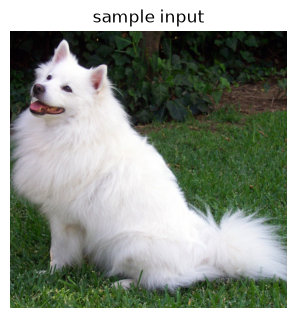

In [39]:
# Stable, well-known ImageNet-class sample used in the PyTorch examples.
SAMPLE_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
SAMPLE_PATH = DATA_DIR / "sample.jpg"

if SAMPLE_PATH.exists():
    print(f"sample image already present -> skipping download  ({SAMPLE_PATH})")
else:
    resp = requests.get(SAMPLE_URL, timeout=30)
    resp.raise_for_status()
    SAMPLE_PATH.write_bytes(resp.content)
    print(f"downloaded {SAMPLE_URL}  ->  {SAMPLE_PATH}")

pil_image = Image.open(SAMPLE_PATH).convert("RGB")

# Model input + a display image (exactly the pixels the model sees).
pixel_values = transform(pil_image).unsqueeze(0)                 # (1, 3, H, W)
_disp = T.CenterCrop(IMAGE_SIZE)(
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BICUBIC)(pil_image))
display_np = np.asarray(_disp)
print("input tensor:", tuple(pixel_values.shape))

plt.figure(figsize=(3.6, 3.6))
plt.imshow(display_np); plt.title("sample input"); plt.axis("off"); plt.show()


## 5. Torch reference features (ground truth)

Run the PyTorch model once. Its dense features are the **reference** every OpenVINO precision
is compared against (both visually and via metrics).


In [40]:
with torch.inference_mode():
    ref_torch = patch_model(pixel_values)          # (1, D, h, w)
print("torch dense features:", tuple(ref_torch.shape))

def to_rows(feat_bdhw):
    """(1, D, h, w) -> (h*w, D) rows, one row per patch, aligned across engines."""
    return feat_bdhw[0].movedim(0, -1).reshape(-1, EMBED).float()

ref_rows = to_rows(ref_torch)                       # (h*w, D)
ref_hwd = ref_torch[0].movedim(0, -1).float()       # (h, w, D) for PCA/seg


torch dense features: (1, 384, 32, 32)


## 6. OpenVINO conversion → FP32 / FP16 / INT8 (NNCF WOQ)

The IRs live in `ov_models/<precision>/` and are named after the input resolution. **The cell
first checks what is already on disk and converts only what is missing**, printing either
`skipping conversion` or `converted` for each precision — so a second run of the notebook goes
straight to inference, while changing `IMAGE_SIZE` transparently triggers a fresh conversion.

When conversion is needed, the torch wrapper is converted to an FP32 OpenVINO model **once**
and the three precisions are derived from it:

- **FP32** — full-precision constants.
- **FP16** — same graph, constants compressed to half precision.
- **INT8 (WOQ)** — `nncf.compress_weights(..., INT8_SYM)`: stores weights as int8 with **no
  calibration data**. At runtime the GPU decompresses them inline and applies its own dynamic
  activation quantization, so matmuls execute in int8 without the extra FP32 dequantization
  overhead that full weight+activation post-training quantization adds — keeping accuracy high
  while running fast on Intel GPUs.


In [41]:
# The IR is exported for a fixed input shape, so the resolution is part of its name:
# changing IMAGE_SIZE transparently triggers a fresh conversion instead of reusing a
# stale graph.
IR_STEM = f"dinov3_vits16_patch_{IMAGE_SIZE}"
ir_paths = {p: OV_DIR / p / f"{IR_STEM}.xml" for p in PRECISIONS}


def ir_on_disk(path):
    """An IR is usable only if both the graph (.xml) and the weights (.bin) exist."""
    return path.exists() and path.with_suffix(".bin").exists()


missing = [p for p in PRECISIONS if not ir_on_disk(ir_paths[p])]
for p in PRECISIONS:
    if p not in missing:
        print(f"  [{p:>4}] IR found -> skipping conversion")

if missing:
    example = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
    ov_fp32 = ov.convert_model(patch_model, example_input=example)
    for p in missing:  # ordered fp32 -> fp16 -> int8, so WOQ runs last
        ir_paths[p].parent.mkdir(parents=True, exist_ok=True)
        model = (nncf.compress_weights(ov_fp32, mode=nncf.CompressWeightsMode.INT8_SYM)
                 if p == "int8" else ov_fp32)
        ov.save_model(model, ir_paths[p], compress_to_fp16=(p != "fp32"))
        print(f"  [{p:>4}] converted")
else:
    print("\nAll IRs are cached; nothing to convert.")

print("\nIRs in ov_models/:")
for p in PRECISIONS:
    mb = ir_paths[p].with_suffix(".bin").stat().st_size / 1e6
    print(f"  [{p:>4}] {mb:6.1f} MB   {ir_paths[p].relative_to(REPO_ROOT)}")


  [fp32] IR found -> skipping conversion
  [fp16] IR found -> skipping conversion
  [int8] IR found -> skipping conversion

All IRs are cached; nothing to convert.

IRs in ov_models/:
  [fp32]   86.3 MB   ov_models/fp32/dinov3_vits16_patch_512.xml
  [fp16]   43.2 MB   ov_models/fp16/dinov3_vits16_patch_512.xml
  [int8]   21.8 MB   ov_models/int8/dinov3_vits16_patch_512.xml


## 7. Run each OpenVINO model on the sample image

Compile each IR on the chosen device and run inference on the same input. For **FP32** we
force true FP32 execution (`INFERENCE_PRECISION_HINT=f32`) because the GPU plugin otherwise
runs an FP32 IR in FP16 by default — which would make the FP32 row secretly FP16.


In [42]:
core = ov.Core()

def compile_ir(precision):
    model = core.read_model(ir_paths[precision])
    model.reshape({0: ov.PartialShape([1, 3, IMAGE_SIZE, IMAGE_SIZE])})
    config = {"INFERENCE_PRECISION_HINT": "f32"} if precision == "fp32" else {}
    return core.compile_model(model, DEVICE, config)

x_np = pixel_values.numpy()
compiled = {}
feats_ov = {}
for p in PRECISIONS:
    cm = compile_ir(p)
    compiled[p] = cm
    out = cm(x_np)[cm.output(0)]          # (1, D, h, w)
    feats_ov[p] = torch.from_numpy(out)
    print(f"  [{p:>4}] output {tuple(out.shape)}")


  [fp32] output (1, 384, 32, 32)
  [fp16] output (1, 384, 32, 32)
  [int8] output (1, 384, 32, 32)


## 8. Fidelity metrics vs the torch model

DINOv3 characterizes its dense features with **cosine similarity**, so that is the headline
metric here — reported both as the **mean** and as the **worst case (min)** over patches —
complemented by **MSE** and **MAE** for the raw numerical error. Metrics are computed per patch
(rows = `h*w` patches, each a `D`-dim feature vector).

The FP32 row is a sanity check: it should be near-perfect (**mean cosim ≈ 1.0**). FP16 and INT8
show how much dense-feature quality each compression step costs.


In [43]:
def feature_metrics(feat_rows, ref_rows):
    """Dense-feature fidelity of one engine vs the torch reference (rows = patches)."""
    feat, ref = feat_rows.float(), ref_rows.float()
    diff = feat - ref
    cos = F.cosine_similarity(feat, ref, dim=1)
    return {
        "mean_cosim": cos.mean().item(),
        "min_cosim": cos.min().item(),
        "mse": torch.mean(diff ** 2).item(),
        "mae": torch.mean(diff.abs()).item(),
    }


metrics = {p: feature_metrics(to_rows(feats_ov[p]), ref_rows) for p in PRECISIONS}

hdr = f"{'prec':>5} {'mean cosim':>12} {'min cosim':>11} {'mse':>12} {'mae':>12}"
print(hdr); print("-" * len(hdr))
for p in PRECISIONS:
    m = metrics[p]
    print(f"{p:>5} {m['mean_cosim']:>12.6f} {m['min_cosim']:>11.4f} "
          f"{m['mse']:>12.3e} {m['mae']:>12.3e}")


 prec   mean cosim   min cosim          mse          mae
--------------------------------------------------------
 fp32     1.000000      1.0000    5.618e-13    5.669e-07
 fp16     0.999998      1.0000    5.929e-07    5.959e-04
 int8     0.999495      0.9985    1.755e-04    1.044e-02


## 9. Throughput & latency

Warm up, then time `BENCH_REPEATS` single-image inferences per engine. Torch runs on CPU as a
reference; the OpenVINO models run on the selected device. Reported: median latency (ms) and
throughput (images/s) at batch 1.


In [44]:
def bench_ov(cm, x_np, repeats=BENCH_REPEATS, warmup=3):
    for _ in range(warmup):
        cm(x_np)
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter(); cm(x_np); ts.append(time.perf_counter() - t0)
    ts = np.array(ts)
    return float(np.median(ts) * 1e3)

def bench_torch(model, x, repeats=BENCH_REPEATS, warmup=3):
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        ts = []
        for _ in range(repeats):
            t0 = time.perf_counter(); model(x); ts.append(time.perf_counter() - t0)
    return float(np.median(np.array(ts)) * 1e3)

perf = {}
perf["torch (cpu, fp32)"] = bench_torch(patch_model, pixel_values)
for p in PRECISIONS:
    perf[f"ov-{p} ({DEVICE})"] = bench_ov(compiled[p], x_np)

hdr = f"{'engine':<22} {'latency_ms':>12} {'img/s':>10}"
print(hdr); print("-" * len(hdr))
for name, lat in perf.items():
    print(f"{name:<22} {lat:>12.2f} {1000.0 / lat:>10.1f}")


engine                   latency_ms      img/s
----------------------------------------------
torch (cpu, fp32)            138.64        7.2
ov-fp32 (GPU)                 47.22       21.2
ov-fp16 (GPU)                  8.47      118.1
ov-int8 (GPU)                  9.31      107.4


## 10. Visualization — PCA & segmentation (torch vs OpenVINO)

Four rows, one column per engine (torch, FP32, FP16, INT8):

1. **input** — the pixels the model sees.
2. **PCA-RGB** — top-3 PCA of the dense features (basis fit on the torch reference and reused
   everywhere, so colours are directly comparable).
3. **segmentation** — KMeans over the patch features (clusters fit on torch, predicted for
   each precision) → semantic regions.
4. **cosine similarity** — per-patch cosine similarity to the torch features (the measure
   DINOv3 and its lineage use to compare dense features, matching the metrics table above).
   A shared colour scale makes the panels comparable; brighter = closer to torch, so any
   precision drop shows up as darker patches.


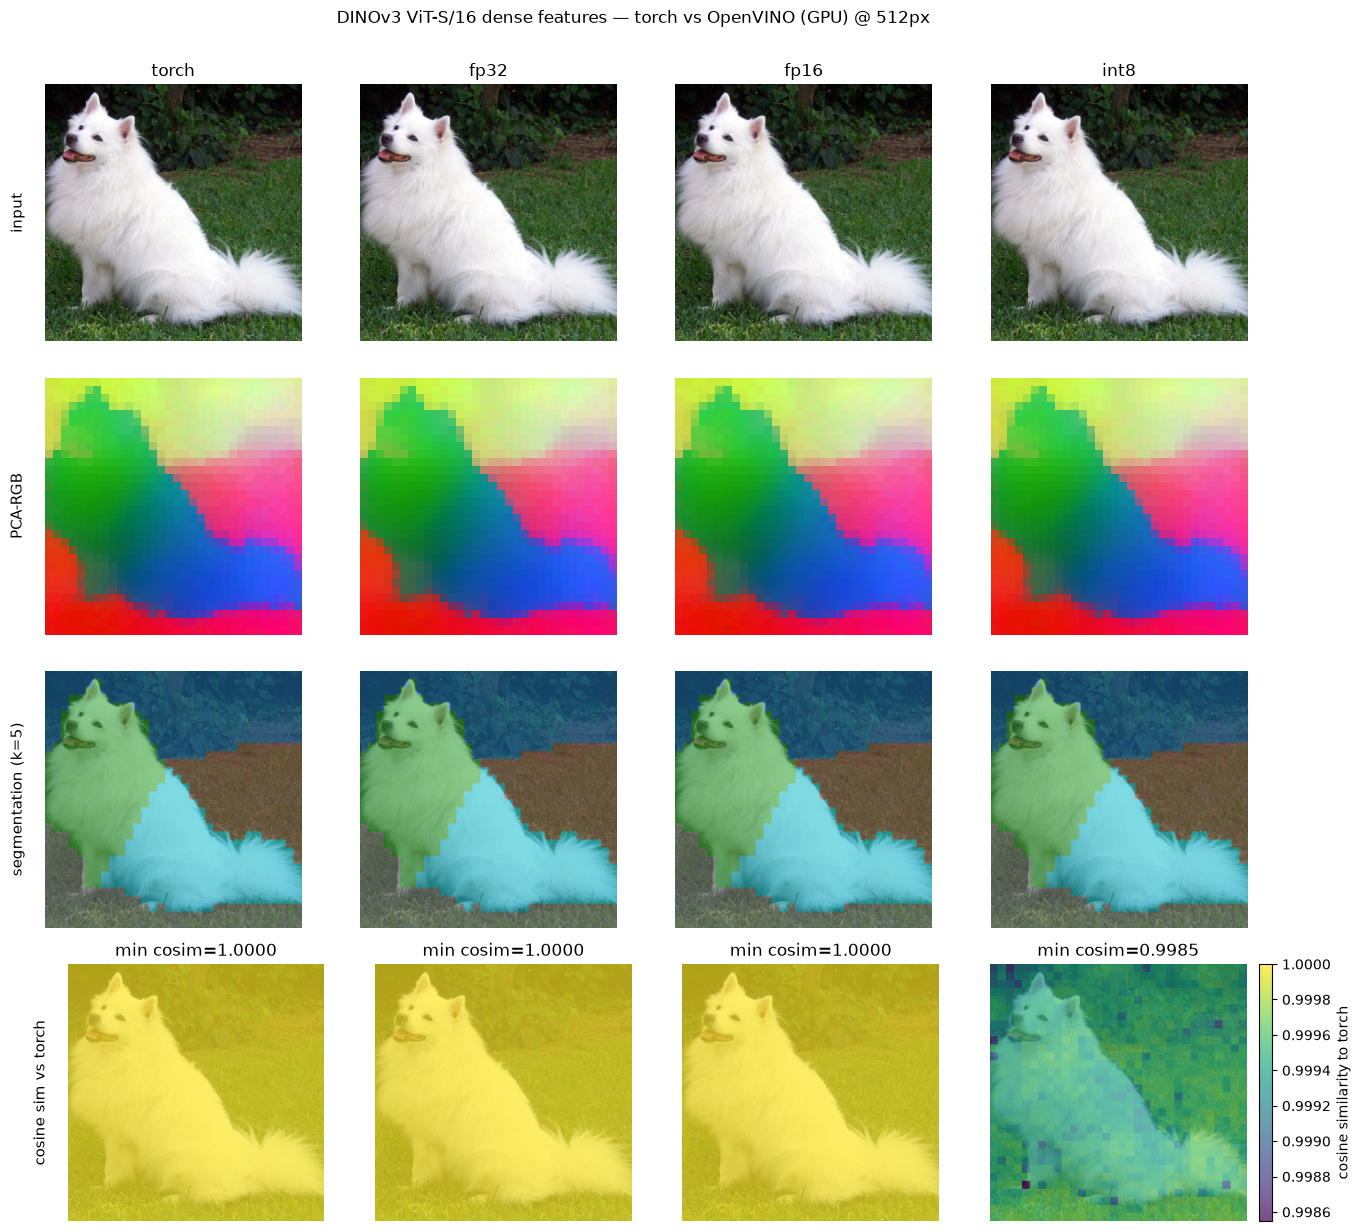

In [45]:
from sklearn.cluster import KMeans

# --- PCA basis: fit ONCE on the torch reference and reuse for every engine ----
# torch.pca_lowrank is randomized, so recomputing it per column would flip the
# sign/rotation and change colours. Fixing one basis makes the columns directly
# comparable (the same feature direction -> the same colour everywhere), so the
# FP32 panel matches torch exactly.
_mean = ref_rows.mean(0, keepdim=True)
_, _, _v = torch.pca_lowrank(ref_rows - _mean, q=3)
_basis = _v[:, :3]
_proj_ref = (ref_rows - _mean) @ _basis
_lo, _hi = _proj_ref.min(0).values, _proj_ref.max(0).values

def pca_rgb(feat_bdhw):
    proj = (to_rows(feat_bdhw) - _mean) @ _basis
    rgb = ((proj - _lo) / (_hi - _lo + 1e-8)).clamp(0, 1)
    return rgb.reshape(GRID, GRID, 3).cpu().numpy()

# --- segmentation: KMeans fit on torch, predicted for every precision ---------
N_SEG = 5
km = KMeans(n_clusters=N_SEG, n_init=10, random_state=0).fit(ref_rows.numpy())

def seg_grid(feat_bdhw):
    return km.predict(to_rows(feat_bdhw).numpy()).reshape(GRID, GRID)

# --- per-patch cosine similarity to the torch reference (DINOv3's dense measure)
def cos_sim_grid(feat_bdhw):
    hwd = feat_bdhw[0].movedim(0, -1).float()
    return F.cosine_similarity(hwd, ref_hwd, dim=-1).numpy()   # (h, w)

def upsample(grid, size, mode="nearest"):
    t = torch.from_numpy(grid.astype(np.float32))[None, None]
    return F.interpolate(t, size=(size, size), mode=mode)[0, 0].numpy()

engines = ["torch"] + list(PRECISIONS)
feat_all = {"torch": ref_torch, **feats_ov}
row_titles = ["input", "PCA-RGB", f"segmentation (k={N_SEG})", "cosine sim vs torch"]

# Cosine-similarity maps; the colour range starts at the worst patch across the
# OpenVINO engines (torch's self-map is all 1.0) so the panels stay comparable
# and any precision loss is visible rather than washed out.
sim_grids = {eng: cos_sim_grid(feat_all[eng]) for eng in engines}
SIM_VMIN = min(float(sim_grids[p].min()) for p in PRECISIONS)

fig, axes = plt.subplots(4, len(engines), figsize=(3.3 * len(engines), 12.2))
for j, eng in enumerate(engines):
    axes[0, j].imshow(display_np); axes[0, j].set_title(eng); axes[0, j].axis("off")
    axes[1, j].imshow(pca_rgb(feat_all[eng])); axes[1, j].axis("off")
    seg = upsample(seg_grid(feat_all[eng]), IMAGE_SIZE)
    axes[2, j].imshow(display_np); axes[2, j].imshow(seg, cmap="tab10", alpha=0.55)
    axes[2, j].axis("off")
    sim = sim_grids[eng]
    axes[3, j].imshow(display_np)
    hm = axes[3, j].imshow(upsample(sim, IMAGE_SIZE), cmap="viridis", alpha=0.7,
                           vmin=SIM_VMIN, vmax=1.0)
    axes[3, j].set_title(f"min cosim={sim.min():.4f}"); axes[3, j].axis("off")

for i, title in enumerate(row_titles):
    axes[i, 0].set_ylabel(title, rotation=90, labelpad=14, fontsize=11)
    axes[i, 0].axis("on"); axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    for spine in axes[i, 0].spines.values():
        spine.set_visible(False)

fig.suptitle(f"DINOv3 ViT-S/16 dense features — torch vs OpenVINO ({DEVICE}) @ {IMAGE_SIZE}px",
             y=1.005)
fig.tight_layout()
fig.colorbar(hm, ax=axes[3, :].tolist(), fraction=0.015, pad=0.01,
             label="cosine similarity to torch")
plt.show()


## 11. Summary

A compact recap of fidelity, latency/throughput and IR sizes, plus where the cached artifacts
live — the next run reuses all of them and jumps straight to inference.


In [46]:
print("=" * 72)
print(f"DINOv3 ViT-S/16 - OpenVINO FP32 / FP16 / INT8-WOQ  (device={DEVICE}, {IMAGE_SIZE}px)")
print("=" * 72)

print("\nFidelity vs torch (dense patch features):")
for p in PRECISIONS:
    m = metrics[p]
    print(f"  {p:>4}: mean cosim={m['mean_cosim']:.5f}  min cosim={m['min_cosim']:.4f}  "
          f"mse={m['mse']:.3e}  mae={m['mae']:.3e}")

print("\nLatency / throughput:")
for name, lat in perf.items():
    print(f"  {name:<22} {lat:7.2f} ms   {1000.0 / lat:7.1f} img/s")

print("\nIR sizes:")
for p in PRECISIONS:
    mb = ir_paths[p].with_suffix('.bin').stat().st_size / 1e6
    print(f"  {p:>4}: {mb:.1f} MB")

print("\nCached artifacts (re-runs skip download + conversion):")
print(f"  weights : {CHECKPOINT_DIR.relative_to(REPO_ROOT)}")
print(f"  image   : {SAMPLE_PATH.relative_to(REPO_ROOT)}")
print(f"  IRs     : {OV_DIR.relative_to(REPO_ROOT)}")
print("\nPipeline OK.")


DINOv3 ViT-S/16 - OpenVINO FP32 / FP16 / INT8-WOQ  (device=GPU, 512px)

Fidelity vs torch (dense patch features):
  fp32: mean cosim=1.00000  min cosim=1.0000  mse=5.618e-13  mae=5.669e-07
  fp16: mean cosim=1.00000  min cosim=1.0000  mse=5.929e-07  mae=5.959e-04
  int8: mean cosim=0.99950  min cosim=0.9985  mse=1.755e-04  mae=1.044e-02

Latency / throughput:
  torch (cpu, fp32)       138.64 ms       7.2 img/s
  ov-fp32 (GPU)            47.22 ms      21.2 img/s
  ov-fp16 (GPU)             8.47 ms     118.1 img/s
  ov-int8 (GPU)             9.31 ms     107.4 img/s

IR sizes:
  fp32: 86.3 MB
  fp16: 43.2 MB
  int8: 21.8 MB

Cached artifacts (re-runs skip download + conversion):
  weights : checkpoints/dinov3-vits16-pretrain-lvd1689m
  image   : data/sample.jpg
  IRs     : ov_models

Pipeline OK.
